# ARIMA + GARCH

В этом ноутбуке:
1. Загружаем стационарный ряд из CSV.
2. Подбираем оптимальные параметры **ARIMA(p,d,q)** по **AIC**.
3. Строим **GARCH(p,q)** на остатках ARIMA (только для стационарного ряда).
4. Проверяем качество модели и делаем выводы.

> Файл по умолчанию: `international_airline_passengers_stationary.csv`

In [1]:
# Если библиотека arch не установлена, раскомментируйте строку ниже:
#!pip install arch

     ---------------------------------------- 0.0/937.9 kB ? eta -:--:--
     - -------------------------------------- 30.7/937.9 kB ? eta -:--:--
     - -------------------------------------- 30.7/937.9 kB ? eta -:--:--
     - -------------------------------------- 30.7/937.9 kB ? eta -:--:--
     - -------------------------------------- 30.7/937.9 kB ? eta -:--:--
     -- ---------------------------------- 61.4/937.9 kB 297.7 kB/s eta 0:00:03
     --- --------------------------------- 92.2/937.9 kB 403.5 kB/s eta 0:00:03
     --- -------------------------------- 102.4/937.9 kB 420.8 kB/s eta 0:00:02
     ----- ------------------------------ 153.6/937.9 kB 510.2 kB/s eta 0:00:02
     --------- -------------------------- 235.5/937.9 kB 722.1 kB/s eta 0:00:01
     --------- -------------------------- 235.5/937.9 kB 722.1 kB/s eta 0:00:01
     --------- -------------------------- 235.5/937.9 kB 722.1 kB/s eta 0:00:01
     ------------ ----------------------- 337.9/937.9 kB 807.1 kB/s eta


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

# Безопасный импорт arch
try:
    import typing
    import coverage

    for name in ["Tracer", "TShouldTraceFn", "TShouldStartContextFn", "TFileDisposition"]:
        if not hasattr(coverage.types, name):
            setattr(coverage.types, name, typing.Any)
    if not hasattr(coverage.types, "Tracer") and hasattr(coverage.types, "TracerCore"):
        coverage.types.Tracer = coverage.types.TracerCore
except Exception:
    pass

from arch import arch_model

## 1. Загрузка данных

Если запускаете локально, укажите свой путь:


In [4]:
# Путь для локального запуска (Windows):
path = r"..\data\processed\mean_monthly_air_temperature_stationary.csv"

df = pd.read_csv(path)
df["date"] = pd.to_datetime(df["date"])
ts = pd.Series(df["value"].values, index=df["date"]).asfreq("MS")

print("Первые строки:")
print(ts.head())
print(f"\nРазмер ряда: {ts.shape[0]}")
print(f"Диапазон дат: {ts.index.min().date()} — {ts.index.max().date()}")

Первые строки:
date
1920-01-01    40.6
1920-02-01    40.8
1920-03-01    44.4
1920-04-01    46.7
1920-05-01    54.1
Freq: MS, dtype: float64

Размер ряда: 240
Диапазон дат: 1920-01-01 — 1939-12-01


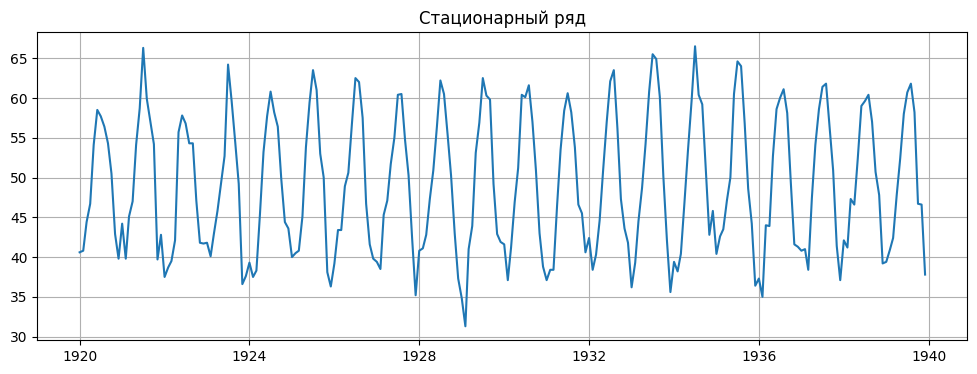

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(ts)
plt.title("Стационарный ряд")
plt.grid(True)
plt.show()

## 2. Проверка стационарности (ADF)

Для GARCH важно, чтобы ряд (или то, на чем строится модель) был стационарным.

In [7]:
adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, adf_icbest = adfuller(ts, autolag="AIC")

print("ADF test:")
print(f"ADF statistic: {adf_stat:.6f}")
print(f"p-value: {adf_p:.6f}")
print(f"lags used: {adf_lags}")
print("Critical values:")
for k, v in adf_crit.items():
    print(f"  {k}: {float(v):.6f}")

# Так как ряд стационарный, используем d = 0
d = 0

ADF test:
ADF statistic: -3.255492
p-value: 0.016989
lags used: 14
Critical values:
  1%: -3.459752
  5%: -2.874473
  10%: -2.573663


## 3. Подбор параметров ARIMA(p,d,q)

Делаем перебор по сетке значений `p` и `q`, выбираем лучшую модель по **AIC**.

In [8]:
arima_results = []

for p in range(0, 6):
    for q in range(0, 6):
        try:
            model = ARIMA(ts, order=(p, d, q), trend="n")
            fit = model.fit()
            arima_results.append({
                "p": p,
                "d": d,
                "q": q,
                "AIC": fit.aic,
                "BIC": fit.bic
            })
        except Exception:
            pass

arima_df = pd.DataFrame(arima_results).sort_values("AIC").reset_index(drop=True)
print("Топ-10 ARIMA по AIC:")
display(arima_df.head(10))

best_row = arima_df.iloc[0]
best_order = (int(best_row["p"]), int(best_row["d"]), int(best_row["q"]))
print(f"Лучшая ARIMA по AIC: {best_order}")

d:\Projects\Project_neto_time\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Projects\Project_neto_time\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Projects\Project_neto_time\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Projects\Project_neto_time\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Projects\Project_neto_time\.venv\lib\site-packages\st

Топ-10 ARIMA по AIC:


d:\Projects\Project_neto_time\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,d,q,AIC,BIC
0,3,0,5,1154.532988,1185.858738
1,4,0,5,1155.551676,1190.358065
2,5,0,5,1206.788691,1245.075719
3,4,0,2,1212.989029,1237.353502
4,5,0,3,1213.031229,1244.356979
5,3,0,2,1237.296589,1258.180423
6,4,0,3,1241.367633,1269.212745
7,5,0,4,1241.642587,1276.448976
8,5,0,1,1246.275165,1270.639638
9,4,0,1,1283.711694,1304.595528


Лучшая ARIMA по AIC: (3, 0, 5)


In [9]:
best_arima = ARIMA(ts, order=best_order, trend="n").fit()

print(best_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  240
Model:                 ARIMA(3, 0, 5)   Log Likelihood                -568.266
Date:                Tue, 24 Feb 2026   AIC                           1154.533
Time:                        18:46:14   BIC                           1185.859
Sample:                    01-01-1920   HQIC                          1167.155
                         - 12-01-1939                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.7315      0.001   2628.453      0.000       2.729       2.734
ar.L2         -2.7314      0.001  -2606.873      0.000      -2.733      -2.729
ar.L3          0.9999   3.85e-05    2.6e+04      0.0

d:\Projects\Project_neto_time\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 4. Диагностика остатков ARIMA

Проверяем:
- есть ли ARCH-эффект (ARCH-LM test),
- есть ли автокорреляция в остатках (Ljung-Box),
- есть ли автокорреляция в квадратах остатков.

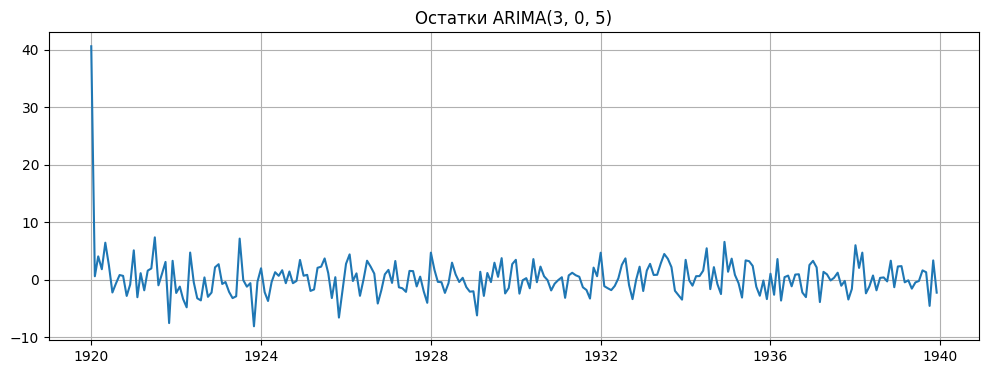

ARCH-LM test on ARIMA residuals:
LM stat = 16.1877, p-value = 0.182788

Ljung-Box (residuals), lag=12:


,lb_stat,lb_pvalue
12,6.841019,0.867938


Ljung-Box (squared residuals), lag=12:


,lb_stat,lb_pvalue
12,0.187769,1.0


In [10]:
resid = best_arima.resid.dropna()

plt.figure(figsize=(12, 4))
plt.plot(resid)
plt.title(f"Остатки ARIMA{best_order}")
plt.grid(True)
plt.show()

arch_lm_before = het_arch(resid, nlags=12)
print("ARCH-LM test on ARIMA residuals:")
print(f"LM stat = {arch_lm_before[0]:.4f}, p-value = {arch_lm_before[1]:.6f}")

lb_resid = acorr_ljungbox(resid, lags=[12], return_df=True)
lb_resid_sq = acorr_ljungbox(resid**2, lags=[12], return_df=True)

print("\nLjung-Box (residuals), lag=12:")
display(lb_resid)

print("Ljung-Box (squared residuals), lag=12:")
display(lb_resid_sq)

## 5. Подбор GARCH(p,q) на остатках ARIMA

GARCH строим на остатках ARIMA (они стационарны, если корректно задана средняя модель).
Для устойчивости оценки часто полезно масштабировать остатки.

In [11]:
resid_scaled = resid * 100  # масштабирование для устойчивости оптимизации

garch_results = []
garch_fits = {}

for p in range(1, 4):
    for q in range(1, 4):
        try:
            gm = arch_model(resid_scaled, mean="Zero", vol="GARCH", p=p, q=q, dist="normal")
            gf = gm.fit(disp="off")
            garch_results.append({
                "garch_p": p,
                "garch_q": q,
                "AIC": gf.aic,
                "BIC": gf.bic
            })
            garch_fits[(p, q)] = gf
        except Exception:
            pass

garch_df = pd.DataFrame(garch_results).sort_values("AIC").reset_index(drop=True)
print("GARCH модели (сортировка по AIC):")
display(garch_df)

best_garch_row = garch_df.iloc[0]
best_garch_order = (int(best_garch_row["garch_p"]), int(best_garch_row["garch_q"]))
print(f"Лучшая GARCH по AIC: GARCH{best_garch_order}")

GARCH модели (сортировка по AIC):


,garch_p,garch_q,AIC,BIC
0,1,1,3373.342408,3383.784325
1,1,2,3375.342408,3389.264963
2,2,1,3375.342408,3389.264964
3,3,1,3377.342408,3394.745602
4,1,3,3377.342408,3394.745602
5,2,2,3377.763176,3395.166371
6,3,2,3379.342408,3400.226241
7,2,3,3379.342408,3400.226241
8,3,3,3381.342408,3405.706880


Лучшая GARCH по AIC: GARCH(1, 1)


In [12]:
best_garch_fit = garch_fits[best_garch_order]
print(best_garch_fit.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.004
Vol Model:                      GARCH   Log-Likelihood:               -1683.67
Distribution:                  Normal   AIC:                           3373.34
Method:            Maximum Likelihood   BIC:                           3383.78
                                        No. Observations:                  240
Date:                Tue, Feb 24 2026   Df Residuals:                      240
Time:                        18:46:25   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      1.3407e+04  3.829e+04      0.350      0.726 

## 6. Диагностика после GARCH

Проверяем стандартизированные остатки:
- исчез ли ARCH-эффект,
- осталась ли автокорреляция.

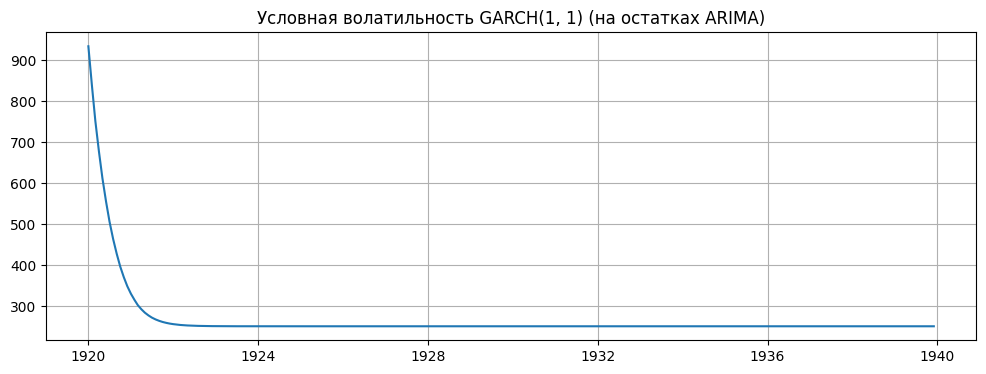

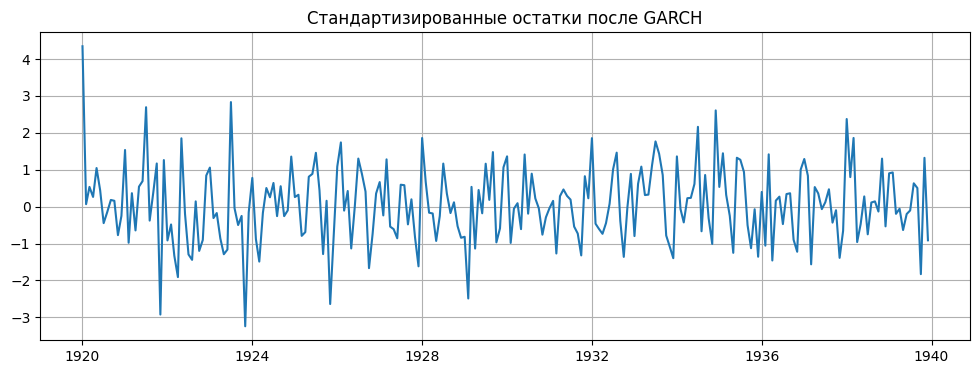

ARCH-LM test on standardized residuals (after GARCH):
LM stat = 12.6250, p-value = 0.396874

Ljung-Box (standardized residuals), lag=12:


,lb_stat,lb_pvalue
12,22.606926,0.031255


Ljung-Box (standardized residuals^2), lag=12:


,lb_stat,lb_pvalue
12,7.088023,0.851742


In [13]:
std_resid = pd.Series(best_garch_fit.std_resid, index=resid.index).dropna()

plt.figure(figsize=(12, 4))
plt.plot(best_garch_fit.conditional_volatility)
plt.title(f"Условная волатильность GARCH{best_garch_order} (на остатках ARIMA)")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(std_resid)
plt.title("Стандартизированные остатки после GARCH")
plt.grid(True)
plt.show()

arch_lm_after = het_arch(std_resid, nlags=12)
print("ARCH-LM test on standardized residuals (after GARCH):")
print(f"LM stat = {arch_lm_after[0]:.4f}, p-value = {arch_lm_after[1]:.6f}")

lb_std = acorr_ljungbox(std_resid, lags=[12], return_df=True)
lb_std_sq = acorr_ljungbox(std_resid**2, lags=[12], return_df=True)

print("\nLjung-Box (standardized residuals), lag=12:")
display(lb_std)

print("Ljung-Box (standardized residuals^2), lag=12:")
display(lb_std_sq)

## 7. Выводы

Для заданного ряда была выполнена проверка стационарности с помощью ADF-теста. Получено p-value = 0.016989 < 0.05, поэтому ряд признан стационарным, и в модели ARIMA использован параметр d = 0.

По критерию AIC среди моделей ARIMA(p,d,q) лучшей оказалась модель ARIMA(3,0,5).

На остатках ARIMA была построена модель GARCH с подбором параметров по критерию AIC. Лучшей оказалась модель GARCH(1,1).

Диагностика после GARCH показала, что ARCH-эффект устранен (ARCH-LM p-value = 0.396874 > 0.05), а также отсутствует автокорреляция в квадратах стандартизированных остатков (Ljung-Box для квадратов: p-value = 0.851742 > 0.05). Это означает, что модель GARCH хорошо описывает волатильность ряда.

Однако в стандартизированных остатках сохраняется автокорреляция (Ljung-Box p-value = 0.031255 < 0.05), что указывает на неполное описание средней компоненты ряда моделью ARIMA(3,0,5). Таким образом, GARCH хорошо подходит для моделирования условной дисперсии, но среднюю часть модели можно дополнительно улучшить (например, за счет другой спецификации ARIMA/SARIMA).